In [1]:
import os

max_depth = 4
base_depth = "/kaggle/input".count(os.sep)
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    depth = dirpath.count(os.sep) - base_depth
    if depth > max_depth:
        dirnames[:] = []
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(dirpath) or dirpath}/  [{len(filenames)} files]  {filenames[:2]}")

input/  [0 files]  []


In [2]:
import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

TARGET_CLASSES = ["adenocarcinoma", "squamous_cell_carcinoma", "large_cell_carcinoma", "normal"]
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}
NUM_CLASSES = len(TARGET_CLASSES)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 35
LEARNING_RATE = 5e-4
EARLY_STOP_PATIENCE = 5

In [ ]:
LABEL_MAP = {
    "adenocarcinoma": "adenocarcinoma",
    "squamous.cell.carcinoma": "squamous_cell_carcinoma",
    "large.cell.carcinoma": "large_cell_carcinoma",
    "normal": "normal",
}

def build_df_from_folder(folder_name):
    split_dir = None
    for dirpath, dirnames, filenames in os.walk(FIGSHARE_DIR):
        if folder_name in dirnames:
            split_dir = os.path.join(dirpath, folder_name)
            break
    if split_dir is None:
        print(f"!! Could not find '{folder_name}'")
        return pd.DataFrame()
    records = []
    for folder in os.listdir(split_dir):
        folder_path = os.path.join(split_dir, folder)
        if not os.path.isdir(folder_path):
            continue
        raw_prefix = folder.split('_')[0]
        label = LABEL_MAP.get(raw_prefix)
        if label is None:
            continue
        for fname in os.listdir(folder_path):
            records.append({"filepath": os.path.join(folder_path, fname), "label": label})
    return pd.DataFrame(records)

_train_part = build_df_from_folder("training images")
_val_part   = build_df_from_folder("validation images")
_test_part  = build_df_from_folder("test images")

full_pool = pd.concat([_train_part, _val_part, _test_part], ignore_index=True)
full_pool = full_pool.sample(frac=1.0, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    full_pool, train_size=0.60, stratify=full_pool["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df), " Val size:", len(val_df), " Test size:", len(test_df))
print("\nTrain class balance:\n", train_df["label"].value_counts())
print("\nVal class balance:\n", val_df["label"].value_counts())
print("\nTest class balance:\n", test_df["label"].value_counts())

Train size: 600  Val size: 200  Test size: 200

Train class balance:
 label
adenocarcinoma             203
squamous_cell_carcinoma    156
normal                     129
large_cell_carcinoma       112
Name: count, dtype: int64

Val class balance:
 label
adenocarcinoma             67
squamous_cell_carcinoma    52
normal                     43
large_cell_carcinoma       38
Name: count, dtype: int64

Test class balance:
 label
adenocarcinoma             68
squamous_cell_carcinoma    52
normal                     43
large_cell_carcinoma       37
Name: count, dtype: int64


In [5]:
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=True, seed=42
)
val_gen = datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=False
)
test_gen = datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, class_mode="categorical",
    classes=TARGET_CLASSES, batch_size=BATCH_SIZE, shuffle=False
)
print("class_indices:", train_gen.class_indices)

Found 600 validated image filenames belonging to 4 classes.
Found 200 validated image filenames belonging to 4 classes.
Found 200 validated image filenames belonging to 4 classes.
class_indices: {'adenocarcinoma': 0, 'squamous_cell_carcinoma': 1, 'large_cell_carcinoma': 2, 'normal': 3}


In [6]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling="avg"
)
base_model.trainable = True  # 100% fine-tuning -- entire backbone trainable from epoch 1

output_layer = Dense(NUM_CLASSES, activation="softmax")(base_model.output)
model = Model(inputs=base_model.input, outputs=output_layer)
model.summary()

model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=LEARNING_RATE),
    metrics=["accuracy"]
)

I0000 00:00:1790592643.836444      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790592643.842344      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 4,012,672 (15.31 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [7]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops(keras_model, batch_size=1):
    """Forward-pass FLOPs for `keras_model` at the given batch size, via TF's graph profiler."""
    input_shape = [batch_size] + list(keras_model.input.shape[1:])
    concrete_func = tf.function(lambda x: keras_model(x)).get_concrete_function(
        tf.TensorSpec(input_shape, keras_model.input.dtype)
    )
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)
    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name="")
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd="op", options=opts)
    return flops.total_float_ops

# --- Trainable-vs-frozen parameter split, read directly from the model (not assumed) ---
trainable_param_count = sum(int(tf.size(w)) for w in model.trainable_weights)
total_param_count = sum(int(tf.size(w)) for w in model.weights)
trainable_fraction = trainable_param_count / total_param_count

TRAINING_FLOPS_MULTIPLIER = 1 + 2 * trainable_fraction  # 1x forward + up to 2x backward, scaled by how much of the model is actually trainable

print(f"Trainable params: {trainable_param_count:,} / {total_param_count:,} total  (trainable_fraction={trainable_fraction:.4f})")
print(f"Derived training FLOPs multiplier: {TRAINING_FLOPS_MULTIPLIER:.4f}x forward\n")

# --- Forward pass ---
flops_per_image_fwd = get_flops(model, batch_size=1)
flops_per_batch_fwd = get_flops(model, batch_size=BATCH_SIZE)

# --- Fine-tuning (forward + backward) ---
flops_per_image_train = flops_per_image_fwd * TRAINING_FLOPS_MULTIPLIER
flops_per_batch_train = flops_per_batch_fwd * TRAINING_FLOPS_MULTIPLIER

steps_per_epoch = len(train_df) // BATCH_SIZE
flops_per_epoch_train = flops_per_batch_train * steps_per_epoch
flops_full_run_train = flops_per_epoch_train * EPOCHS  # upper bound -- ignores early stopping cutting epochs short

print("=== Forward pass ===")
print(f"Per image:  {flops_per_image_fwd:,} FLOPs  (~{flops_per_image_fwd/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_fwd:,} FLOPs  (~{flops_per_batch_fwd/1e9:.3f} GFLOPs)")

print(f"\n=== Fine-tuning (forward + backward, ~{TRAINING_FLOPS_MULTIPLIER:.2f}x forward) ===")
print(f"Per image:  {flops_per_image_train:,} FLOPs  (~{flops_per_image_train/1e9:.3f} GFLOPs)")
print(f"Per batch (batch_size={BATCH_SIZE}):  {flops_per_batch_train:,} FLOPs  (~{flops_per_batch_train/1e9:.3f} GFLOPs)")
print(f"\nSteps per epoch: {steps_per_epoch}  (train set size {len(train_df)} / batch size {BATCH_SIZE})")
print(f"Per epoch:  {flops_per_epoch_train:,} FLOPs  (~{flops_per_epoch_train/1e12:.3f} TFLOPs)")
print(f"Full {EPOCHS}-epoch run (upper bound, no early stopping):  {flops_full_run_train:,} FLOPs  (~{flops_full_run_train/1e15:.3f} PFLOPs)")

Trainable params: 4,012,672 / 4,054,695 total  (trainable_fraction=0.9896)
Derived training FLOPs multiplier: 2.9793x forward



I0000 00:00:1790592648.384454      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1790592648.384624      58 single_machine.cc:376] Starting new session
I0000 00:00:1790592648.399041      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790592648.400620      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation ker

I0000 00:00:1790592651.730844      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1790592651.731048      58 single_machine.cc:376] Starting new session
I0000 00:00:1790592651.747047      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790592651.748640      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

## 7. Callbacks

In [8]:
callbacks = [
    ModelCheckpoint("best_effnetb0_figshare_224.keras", monitor="val_accuracy", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True, verbose=1),
]

In [9]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/35


2026-09-28 10:51:40.750067: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 10:51:40.889665: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 10:51:41.214816: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 10:51:41.357135: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 10:51:42.135550: E external/local_xla/xla/stream_

12/38 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.4537 - loss: 1.1996

2026-09-28 10:52:23.026409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 10:52:23.161504: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 10:52:23.478340: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 10:52:23.619513: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-28 10:52:24.394730: E external/local_xla/xla/stream_

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5700 - loss: 0.9687
Epoch 1: val_accuracy improved from None to 0.62000, saving model to best_effnetb0_figshare_224.keras

Epoch 1: finished saving model to best_effnetb0_figshare_224.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.6950 - loss: 0.7204 - val_accuracy: 0.6200 - val_loss: 0.8808
Epoch 2/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9151 - loss: 0.2240
Epoch 2: val_accuracy improved from 0.62000 to 0.84500, saving model to best_effnetb0_figshare_224.keras

Epoch 2: finished saving model to best_effnetb0_figshare_224.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.9267 - loss: 0.2078 - val_accuracy: 0.8450 - val_loss: 0.3905
Epoch 3/35
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9684 - loss: 0.0995
Epoch 3: val_accuracy did not improve from 0.84500
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.9583 - loss: 0.1203 - val_accuracy: 0.7550 - val_loss: 0.6224
Epoch 4/35
38/

## 9. Plot train/val loss + accuracy

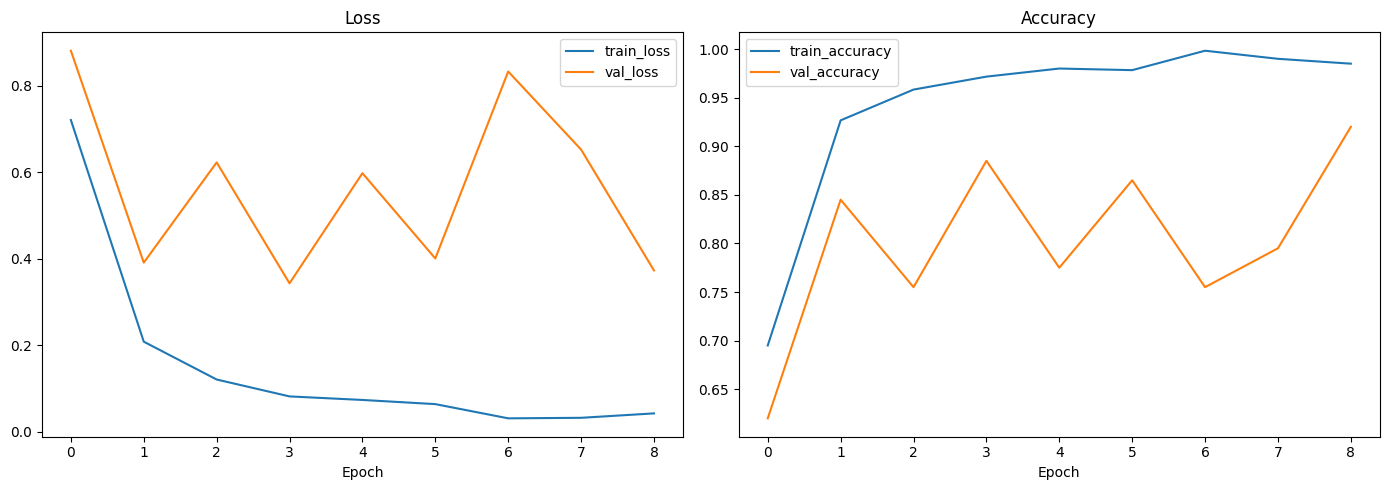

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="train_loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train_accuracy")
axes[1].plot(history.history["val_accuracy"], label="val_accuracy")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_effnetb0_figshare_224.png", dpi=150)
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 400ms/step - accuracy: 0.8900 - loss: 0.3565
Test loss: 0.3565  Test accuracy: 0.8900

Classification Report:
                         precision    recall  f1-score   support

         adenocarcinoma     0.7805    0.9412    0.8533        68
squamous_cell_carcinoma     0.9388    0.8846    0.9109        52
   large_cell_carcinoma     1.0000    0.6757    0.8065        37
                 normal     0.9773    1.0000    0.9885        43

               accuracy                         0.8900       200
              macro avg     0.9241    0.8754    0.8898       200
           weighted avg     0.9046    0.8900    0.8887       200

Test macro F1: 0.8898

Prediction distribution:
adenocarcinoma             82
squamous_cell_carcinoma    49
normal                     44
large_cell_carcinoma       25
Name: count, dtype: int64


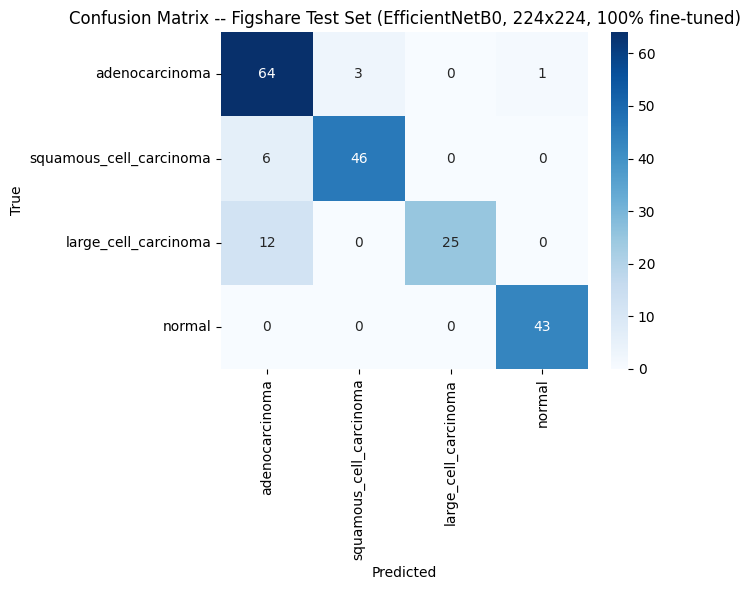


EfficientNetB0 (Figshare, 224x224) test accuracy: 89.00%


In [11]:
best_model = tf.keras.models.load_model("best_effnetb0_figshare_224.keras")

test_gen.reset()
test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

test_gen.reset()
y_pred_probs = best_model.predict(test_gen, verbose=0)
y_pred_idx = np.argmax(y_pred_probs, axis=1)
y_true_idx = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true_idx, y_pred_idx, target_names=TARGET_CLASSES, digits=4))

test_macro_f1 = f1_score(y_true_idx, y_pred_idx, average="macro")
print(f"Test macro F1: {test_macro_f1:.4f}")

print("\nPrediction distribution:")
print(pd.Series(y_pred_idx).map({i: c for i, c in enumerate(TARGET_CLASSES)}).value_counts())

cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix -- Figshare Test Set (EfficientNetB0, 224x224, 100% fine-tuned)")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_effnetb0_figshare_224.png", dpi=150)
plt.show()

print(f"\nEfficientNetB0 (Figshare, 224x224) test accuracy: {test_acc*100:.2f}%")